<center><u><H1>Polynomial Regression</H1></u></center>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from sklearn.datasets import load_boston
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
%matplotlib inline

In [4]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

## Preprocessing:

In [5]:
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

df = pd.DataFrame(data, columns=columns)
df['Price'] = target

In [6]:
# LSTAT: percent lower status of the population
X = df['LSTAT'].values 
y = df['Price'].values

In [7]:
X = X[:, np.newaxis]
y = y[:, np.newaxis]

In [8]:
lr = LinearRegression()

## Creating polynomial models

In [9]:
quadratic = PolynomialFeatures(degree=2)

In [10]:
cubic = PolynomialFeatures(degree=3)

In [11]:
X_quad = quadratic.fit_transform(X)

In [12]:
X_cubic = cubic.fit_transform(X)

In [13]:
X_plot = np.arange(X.min(), X.max(), 0.5)[:, np.newaxis]
X_plot.shape

(73, 1)

In [14]:
lr = lr.fit(X, y)

In [15]:
lr_pred = lr.predict(X_plot)

In [16]:
linear_r2 = r2_score(y, lr.predict(X))
linear_r2

0.5441462975864797

In [17]:
pr_quad = lr.fit(X_quad, y)

In [18]:
pr_quad_pred = pr_quad.predict(quadratic.fit_transform(X_plot))

In [19]:
quadratic_r2 = r2_score(y, pr_quad.predict(X_quad))
quadratic_r2

0.6407168971636612

In [20]:
pr_cubic = lr.fit(X_cubic, y)

In [21]:
pr_cubic_pred = pr_cubic.predict(cubic.fit_transform(X_plot))

In [22]:
cubic_r2 = r2_score(y, pr_cubic.predict(X_cubic))
cubic_r2

0.6578476405895719

## Plotting models:

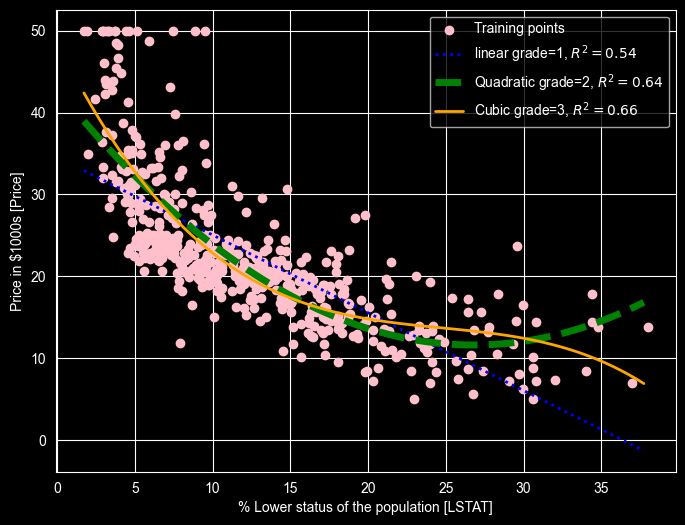

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, label='Training points', color='pink')
plt.plot(X_plot, lr_pred, label='linear grade=1, $R^2=%.2f$' % linear_r2,
        color='blue', lw=2, linestyle=':')
plt.plot(X_plot, pr_quad_pred, label='Quadratic grade=2, $R^2=%.2f$' % quadratic_r2,
        color='green', lw=5, linestyle='--')
plt.plot(X_plot, pr_cubic_pred, label='Cubic grade=3, $R^2=%.2f$' % cubic_r2,
        color='orange', lw=2, linestyle='-')

plt.xlabel('% Lower status of the population [LSTAT]')
plt.ylabel('Price in $1000s [Price]')
plt.legend(loc='best')
plt.show()

## Reference:

http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html